In [1]:
import pandas as pd
import psycopg2
import pandas as pd
import geopandas as gpd
import requests
from geopandas.tools import sjoin
import time
import datetime
from collections import Counter 
import re
import random
import numpy as np
import unidecode

In [2]:
df_patients = pd.read_csv("../../data/data_octobre_2023/Pseudonymisation_provisoire.csv", sep=";",encoding_errors='ignore')

df_patients.rename(columns={'adresse':'ADRESS'}, inplace=True)
#df_patients.dropna(subset='ADRESS'
#)
df_patients.dropna()

,pseudo_provisoire,ADRESS,codepost,nom_commune_postal
0,1,34 RUE DES FRERES CHAUSSONS,92600,ASNIERES-SUR-SEINE
1,2,11 RUE EMILE DUBOIS,75014,PARIS
2,3,48 CHEMIN VERT,78680,EPONE
3,4,18 ALLEE DE LA CHARNILLE,47140,SAINT-SYLVESTRE-SUR-LOT
4,5,31 RUE DU GENERAL DE MIRIBEL,92500,RUEIL-MALMAISON
...,...,...,...,...
64289,64290,3 AV DE FOUILLEUSE,92210,SAINT-CLOUD
64290,64291,81 COTE DU TORCHON,27220,L'HABIT
64291,64292,60 RUE BAUDRICOURT,75013,Paris 13
64292,64293,159 AVENUE DE LA REPUBLIQUE,92320,CHATILLON


## Frequence sur adresse non géocodées => fournies par patients 

In [3]:
mots = df_patients["ADRESS"].str.split(expand=True).stack()
mot_sans_accents = [ unidecode.unidecode(mot) for mot in mots]

mots_up = [mot.upper() for mot in mot_sans_accents]

#print(mots_up)


In [4]:

liste_freq = ["rue", "a","de","du", "des","le","les","place","av","d","place","impasse","la", "l","avenue",
              "square" "allée","allee","bis","BOULEVARD","chemin","route","JEAN","PIERRE","PAUL","HENRI","CHARLES",
              "Paris","sur","ST",'Billancourt',"BOULOGNE","MOULINEAUX","ISSY","SEINE","MARNE","BOIS","BD","SOUS","AVE",
              "NEUILLY","EN","VANVES","SAINT","SQUARE","MALAKOFF","E","MONTROUGE","R","GENERAL","VICTOR","ALL","MEUDON",
              "FONTENAY","GEORGES","CLAMART","CHATILLON","COLOMBES","QUAI","ORGE","DENIS","LECLERC","VILLA","LOUIS",
             "SEVRES","FOSSES","PERRET","PONT","MAUR","BLD","ALLÉE","VERSAILLES","CROIX","JAURES","LECOURBE","HUGO","EMILE",
              "MONTREUIL","VAUGIRARD","JULES","COURBEVOIE","TER","STE","BVD","FAURE","MOULIN","JACQUES","GAULLE","CONVENTION",
              "REPUBLIQUE","LOURMEL","FELIX","GRENELLE","NIVERT","AUGUSTE","MAURICE","GRANDE","PASTEUR","VERDUN","B","ROBERT",
              "MICHEL","MARCEL","PASSAGE","GABRIEL","LEON","CHATEAU","CLOS","ALBERT","PARC","CLAUDE","FONTAINE","FRANCOIS","DR",
              "JAVEL","ZOLA","FRANCE","PORTE","DOCTEUR","FRERES","ANDRE","BALARD","ARISTIDE","ERNEST","MARECHAL","MARTIN","EDOUARD",
            "CARNOT","RAYMOND","GAMBETTA","BRIAND","GAL","VAILLANT","CITE","PERI","EUGENE","TOUR","ROGER","VOLTAIRE","THEATRE","MARIE",
             "HAMEAU","ANTOINE","MARIE","GALLIENI","ET","FOCH","VERT","SUFFREN","ABBE","EGLISE","CHAMPS","BRANCION","PETIT",
             "BARBUSSE","ANATOLE","RENE","BERNARD","STALINGRAD","LEFEBVRE","CURIE","MURAT","GÉNÉRAL","JEANNE","ANGE","VIOLET","J","ETIENNE",
             "BLOMET","EXELMANS","VASCO","GROULT","BROSSOLETTE","DESNOUETTES","AUX","JOSEPH","RENAN","GAMA","BAPTISTE","GERMAIN","FAUBOURG",
             "BLERIOT","COLONEL","CAMILLE","ROUSSEAU","SQ","GARE","FERRY","OLIVIER","COUTURIER","AMIRAL","MOZART","GASTON","COMMERCE","COURS",
             "PRESIDENT","ENTREPRENEURS","C","DOMINIQUE","SAINTE","HOCHE","GUSTAVE","RASPAIL","FREDERIC","ROUSSIN","LEBLANC","GARIBALDI",
             "BLANCHE","BOILEAU","CEVENNES","FALGUIERE","ALEXANDRE","ALFRED","SEBASTIEN","SALENGRO","PHILIPPE","PAIX","FONDARY","MONT","MAINE",
              "PRES","GRAND","VINCENT","PORT","ALPHONSE","MAI","DIVISION","DIDEROT","PEUPLIERS","MERCIER","-","BELLEVUE","EDMOND","VIGNES","VIEUX",
             "NATIONALE","DANTZIG","CLEMENT","VAL","HONORE","MOTTE","BRUNE","POINT","CAMBRONNE","SERRES","MONTAGNE","CHARDON","TEMPLE","WILSON",
             "F","SIMON","DAME","DIDOT","NOTRE","MAIL","RTE","L'EGLISE","JOFFRE","PARMENTIER","DANTON","BOURDONNAIS","FEDERATION","MADEMOISELLE",
             "BEL","BLV","CAPITAINE","FERDINAND","VIA","FERNAND","MARCEAU","LOSSERAND","DOUMER","CLEMENCEAU","PLANTES","GUY","VOUILLE","G","PEIGNOT",
              "BERGERS","BAS","BERGERS","LAGACHE","MORILLONS","BLANC","MERMOZ","TILLEULS","POMPE","ROUX","ALESIA","SUCHET","CRESSON","BARGUE","HENRY",
             "NICOLAS","REINE","RÉPUBLIQUE","BERT","AVN","EMERIAU","LOUISE","PL","KENNEDY","AIR","P","ACACIAS","COMMANDANT","RENOIR","SENTIER","CHAPELLE",
             "COUR","MIDI","BP","LIBERATION","GUESDE","FOUCHER","GINOUX","VILLE","BUISSON","BLUM","ADOLPHE","MONTPARNASSE","ARC","ALLENDE","BOSQUET",
             "MICHELET","CORENTIN","N","KELLER","LAMBERT","CHARONNE","M","EDGAR","PROMENADE","FBG","RANELAGH","THEOPHILE","IMP","CLICHY","BRETEUIL",
              "MAIRIE","LAMARTINE","MARS","DAVID","MIRABEAU","RODIN","BELLEVILLE","GEORGE","UNIVERSITE","AU","LUCIEN","PROCESSION","SABLONS","SALVADOR",
              "MARC","VILLIERS","BERTHELOT","CHARENTON","GUTENBERG","L'ABBE","LIBERTE","EXUPERY","ECOLES","MOLIERE","LETELLIER","CASTAGNARY","L'",
              "LEPELLETIER","JUIN","FERME","DOMAINE","ALLE","SAND","PRE","BRETAGNE","BRANLY","NOVEMBRE","CHAMP","SADI","ARMAND","DESAIX","BAC","BV",
              "DANIEL","GUYNEMER","GL","VOIE","BOURG","RICHARD","KLEBER","LORRAINE","MARCHE","NORMANDIE","LILAS","RAYNOUARD","POINCARE","LAURENT","GROS",
              "DOLET","SENTE","REUILLY","PABLO","NECKER","PICPUS","RUELLE","AMBROISE","ESTIENNE","GAUTIER","MARIDOR","PASSY","CAUCHY","TOLBIAC","LACORDAIRE",
             "JOUR","VOISINS","GARENNE","BLANQUI","TERRASSE","YVES","BOURGOGNE","VALLEE","ALSACE","MARGUERITE","L'AMIRAL","ROUGET","SAENS","GRANDS","LAKANAL",
             "NEUVE","ARAGO","DUMONT","DUMAS","COURCELLES","STRASBOURG","BELLE","FLERS","CHOISY","THOMAS","FRANKLIN","FLEURY","CHERCHE","SOURCE","SEGUR",
             "BERLIOZ","PYRENEES","ROLLIN","GERGOVIE","MARE","PLAINE","PERE","FREMICOURT","THIERS","ESPLANADE","CASANOVA","LEFEVRE","LATTRE","MAL","VERCINGETORIX",
             "ALLERAY","h","MAUBOURG","TASSIGNY","REGNAULT","MADELEINE","MADAME","GRENIER","SILLY","ERLANGER","LOT","EBOUE","BLEUZEN","PICQUET","ROBESPIERRE","PICASSO",
              "DORMOY","FABIEN","HAUT","LUCIE","LAVOISIER","PASCAL","ORVES","S","FORET","RABELAIS","ROLLAND","GUILLAUME","BELLES","V","LEDRU","JARDINS","ROSES","FINLAY",
             "ROMAIN","JOUVENET","DEBUSSY","ROYAL","CHERIOUX","VAUGELAS","MONTMORENCY","LIEU","DAUMESNIL","VAN","VOISIN","FERBER","JUGE","LONGCHAMP","DIT","LEGER","QUINET",
             "ILE","DURANTON","LAURISTON","MATHURIN","COTE","/"]

##HOPITAL : RUE DE L'HOPITAL ET HOPITAL ...
##MAISON : MAION RETRAITE ET RUE HAUTE MAISON...  

##J'AI CONSIDÉRÉ QU'EN DESSOUS DE 500 OCCURENCES CELA N'ÉTAIS PAS CONSIDÉRÉ COMME DU BRUIT 

freq = set(mot.upper() for mot in liste_freq)
mots_simple= [mot for mot in mots_up if mot not in freq ]
mots_simplified = [mot for mot in mots_simple if not re.fullmatch(r'\d+',mot)]

count = Counter(mots_simplified) 
mots_freq = count.most_common()
co = pd.DataFrame(mots_freq, columns = ["bruit", "count"])



In [5]:
co["taux%"] = (co["count"]*100)/len(co)
co["taux%"] = co["taux%"].apply(lambda x: round(x,2) )
co[:18]

,bruit,count,taux%
0,RESIDENCE,1417,6.35
1,CHEZ,1138,5.10
2,APPT,844,3.78
3,BAT,796,3.57
4,MME,570,2.55
5,APPARTEMENT,510,2.28
6,BATIMENT,457,2.05
7,MR,391,1.75
8,RES,277,1.24
9,ETAGE,246,1.10


In [6]:
import plotly.express as px 
fig = px.histogram(co[:150], x="bruit",y="count")
fig.show()

#### biais fréquents et leur occurence 


In [45]:
df = co[:150]


In [6]:
##biais fréquents et leur occurence 

mots_interessants = ["RESIDENCE","CHEZ","BAT","APPT","MME","MR","RES","HOPITAL","MAISON","RETRAITE","CENTRE","HOTEL","QUARTIER"]
#mots_interessants = [ "RESIDENCE","CHEZ","HOPITAL","SDF","RES","MME","BAT","MAISON","MR","HOTEL","LOTISSEMENT","CENTRE","QUARTIER","APPT", "SANTE", "RETRAITE", "HOP"]
#mots_interessants = co["bruit"][:13].to_list()

df_filtre = co[co["bruit"].isin(mots_interessants)]

df_filtre = df_filtre.reset_index(drop=True)

df_filtre


,bruit,count,taux%
0,RESIDENCE,1417,6.35
1,CHEZ,1138,5.10
2,APPT,844,3.78
3,BAT,796,3.57
4,MME,570,2.55
5,MR,391,1.75
6,RES,277,1.24
7,MAISON,122,0.55
8,QUARTIER,84,0.38
9,CENTRE,40,0.18


## Fréquence biais joint

In [7]:
#bruit = [ "RESIDENCE","CHEZ","HOPITAL","SDF","RES","MME","BAT","MAISON","MR","HOTEL","LOTISSEMENT","CENTRE","QUARTIER","APPT", "SANTE", "RETRAITE", "HOP"]
bruit = mots_interessants

df = df_patients.dropna(subset="ADRESS")

table = np.zeros((len(df_filtre),len(df_filtre)), dtype=int)

##+1 lorsque les deux mots sont présents dans la meme phrase 

for row in df.index: ##iteration sur les lignes des adresses     
    if row%100 ==0 : 
        print(f"iteration over the {row}th row")
        
    for i in range(len(bruit)):
        for j in range(len(bruit)): ##it sur l'ensemble des mots frequents 
            
            if i == j :
                table[i,j]=0
            else : 
                bruit_i = df_filtre.loc[i,'bruit']
                bruit_j = df_filtre.loc[j,'bruit']

                add = df.loc[row,"ADRESS"]
                
                if bruit_i in add.split() and bruit_j in add.split():
                    table[i,j]+=1

df_table = pd.DataFrame(table, columns = df_filtre["bruit"], index = df_filtre["bruit"])

iteration over the 0th row
iteration over the 10th row
iteration over the 20th row
iteration over the 30th row
iteration over the 40th row
iteration over the 50th row
iteration over the 60th row
iteration over the 70th row
iteration over the 80th row
iteration over the 90th row
iteration over the 100th row
iteration over the 110th row
iteration over the 120th row
iteration over the 130th row
iteration over the 140th row
iteration over the 150th row
iteration over the 160th row
iteration over the 170th row
iteration over the 180th row
iteration over the 190th row
iteration over the 200th row
iteration over the 210th row
iteration over the 220th row
iteration over the 230th row
iteration over the 240th row
iteration over the 250th row
iteration over the 260th row
iteration over the 270th row
iteration over the 280th row
iteration over the 290th row
iteration over the 300th row
iteration over the 310th row
iteration over the 320th row
iteration over the 330th row
iteration over the 340th 

In [10]:
df_table

bruit,RESIDENCE,CHEZ,APPT,BAT,MME,MR,RES,MAISON,QUARTIER,CENTRE,RETRAITE,HOTEL,HOPITAL
bruit,,,,,,,,,,,,,
RESIDENCE,0,17,94,109,6,4,0,5,6,1,1,3,0
CHEZ,17,0,23,19,506,350,3,1,3,2,0,3,1
APPT,94,23,0,128,13,9,26,0,3,2,0,2,0
BAT,109,19,128,0,8,7,33,1,2,1,1,0,1
MME,6,506,13,8,0,54,2,0,1,2,0,0,1
MR,4,350,9,7,54,0,0,0,1,0,0,1,0
RES,0,3,26,33,2,0,0,0,0,0,0,0,1
MAISON,5,1,0,1,0,0,0,0,2,0,33,0,0
QUARTIER,6,3,3,2,1,1,0,2,0,0,0,0,0


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

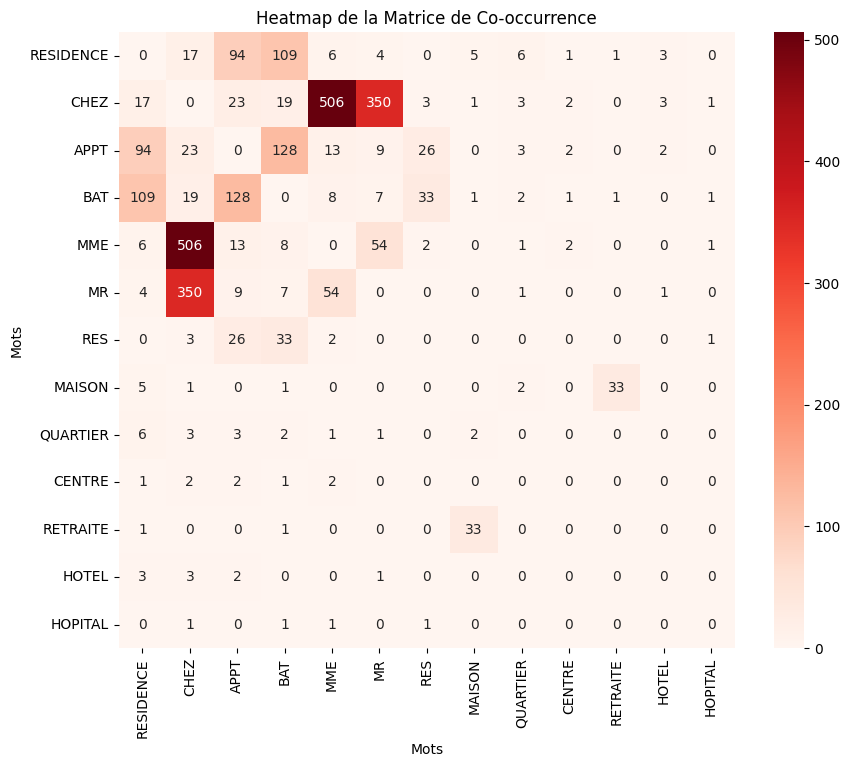

In [13]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(df_table, annot=True,fmt="g", cmap='Reds', square=True)
plt.title("Heatmap de la Matrice de Co-occurrence")
plt.ylabel("Mots")
plt.xlabel("Mots")
plt.show()

fig.savefig('./figure_matrice.png')

In [8]:
df_table.to_csv("./biais/frequence_biais.csv",sep=";")

In [11]:
def get_top_associations(matrix, top_n=5):
    # Ignorer la diagonale et prendre la partie supérieure de la matrice
    tri_upper = np.triu(matrix, k=1)
    
    # Créer un DataFrame à partir de la matrice triangulaire
    df = pd.DataFrame(tri_upper, columns=matrix.columns, index=matrix.index)
    
    # Obtenir les paires et les fréquences
    pairs = [(index, col, df.at[index, col]) for col in df.columns for index in df.index if df.at[index, col] > 0]
    
    # Trier par fréquence
    sorted_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    
    return sorted_pairs[:top_n]

# Afficher les paires de mots les plus fréquemment associés
top_associations = get_top_associations(df_table)
print("Top associations:", top_associations)

Top associations: [('CHEZ', 'MME', 506), ('CHEZ', 'MR', 350), ('APPT', 'BAT', 128), ('RESIDENCE', 'BAT', 109), ('RESIDENCE', 'APPT', 94)]


## Fonction utile pour analyse des mots présents : 

In [ ]:
def filtrer_dataframe_par_mot(df, mot):
    """
    Filtre un DataFrame pour obtenir les lignes où un certain mot apparaît dans une colonne spécifiée.

    :param df: DataFrame à filtrer.
    :param colonne: Nom de la colonne où chercher le mot.
    :param mot: Mot à chercher dans la colonne.
    :return: DataFrame filtré.
    """
    # Filtrer le DataFrame pour les lignes où 'mot' apparaît dans 'colonne'
    return df[df["ADRESS"].str.contains(mot, case=False, na=False)]


filtrer_dataframe_par_mot(df_patients, "CZ")